# Working with complicated dataset

Your name: Sana Al Hamimidi

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [8]:
import pandas as pd
import urllib.request
from io import StringIO

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

# read whole file
with urllib.request.urlopen(url) as f:
    text = f.read().decode("utf-8")

lines = text.splitlines()

# find the header line that contains Fields
fields_line = None
for line in lines:
    if "Fields:" in line:
        fields_line = line
        break


fields_line = fields_line.split('"')[1]

# remove the beginning label
fields_line = fields_line.replace("# Fields: ", "")

# split into column names
fields = [col.strip() for col in fields_line.split(",")]

# read data rows only
data_lines = [line for line in lines if not line.startswith("#") and not line.startswith('"#')]
data_text = "\n".join(data_lines)

df = pd.read_csv(StringIO(data_text), header=None)
df = df.iloc[:, :len(fields)]
df.columns = fields

# clean columns
df["bonds"] = df["bonds"].astype(str).str.replace(",", "", regex=False).str.strip()
df["bonds"] = pd.to_numeric(df["bonds"], errors="coerce")
df["publications"] = pd.to_numeric(df["publications"], errors="coerce")

# drop first column and set index
df = df.drop(columns=["query acc.ver"])
df = df.set_index("subject acc.ver")

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0


### Question 2
What is the average number of publications?

In [4]:
df["publications"].mean()

np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [5]:
df[df["bonds"] > 15000].index.tolist()

['AGK29621.1',
 'AHG32084.1',
 '6G2J_H',
 'YP_002791042.1',
 'AGK29634.1',
 '0806162F',
 'YP_009112408.1',
 'YP_001876469.1',
 'YP_009092269.1',
 'AHG32149.1',
 'YP_009092074.1',
 'YP_009450474.1',
 'YP_004123270.1',
 'YP_009092073.1',
 'AHZ60901.1',
 'YP_004123350.1',
 'YP_009453754.1',
 'ADD46492.1',
 'YP_007025968.1',
 'YP_009453806.1',
 'YP_007024956.1',
 'ASM92364.1',
 'YP_006073044.1',
 'ASM92494.1',
 'ADG95699.1',
 'YP_004891275.1',
 'YP_009166014.1',
 'YP_009538416.1',
 'YP_009414182.1',
 'YP_009178854.1',
 'YP_009414415.1',
 'YP_009353908.1',
 'YP_009093743.1',
 'ABX45285.1',
 'YP_009414156.1',
 'YP_009414363.1']

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

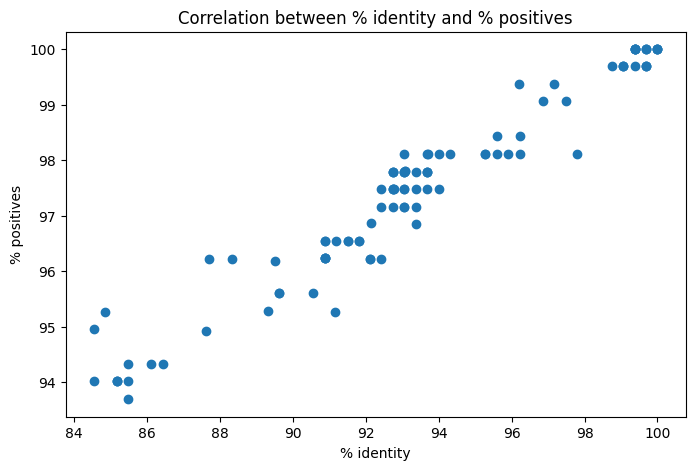

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["% identity"], df["% positives"])
plt.xlabel("% identity")
plt.ylabel("% positives")
plt.title("Correlation between % identity and % positives")
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [7]:
protein_url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein_df = pd.read_csv(protein_url)

df = df.merge(protein_df, how="left", left_index=True, right_on="Protein")
df = df.drop(columns=["Protein"])
df.index.name = "subject acc.ver"

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Unnamed: 0,Source
subject acc.ver,,,,,,,,,,,,,,,
0.0,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,0.0,RefSeq
NaN,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN,NaN
1.0,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,2.0,GenPept
NaN,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN,NaN
NaN,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN,NaN
